In [ ]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt

import pymaster as nmt
import sys
sys.path.append('../')
# from scripts.true_cmb import true_cmb

from scripts.compute_decoupled_cl import compute_decoupled_cl
from scripts.cosine_smoothed_mask import cosine_smoothed_mask
from scripts. compute_weights import compute_weights
from scripts.mask_maps import mask_maps
from scripts.compute_alm_ilc import compute_alm_ilc
from scripts.apply_HILC import apply_HILC
from scripts.simulate_planck_maps import simulate_planck_maps

In [83]:
nside=256
npix=hp.nside2npix(nside)
nsims=10
lmax= 2*nside  #3*nside -1 
almsize=hp.Alm.getsize(lmax)
ells =np.arange(2,lmax+1)
print(ells.shape)
norm= (ells*(ells+1))/(2*np.pi)
freq = np.array([28.4,  44.1,  70.4,  100.0,  143.0,  217.0,  353.0])
n_freqs = len(freq)

(511,)


In [84]:
print(norm.shape)

(511,)


In [85]:
mask= cosine_smoothed_mask(nside)
mask= (mask*(-1))+1

In [88]:
def true_cmb() -> np.ndarray:
    """
    Generates the true CMB power spectrum using PySM3.
    
    Returns:
        cl_cmb (np.ndarray): true CMB power spectrum.
    """
    
    cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat", max_rows=lmax ,usecols=(1)) #skiprows=0,

    return cl_th

In [91]:
cmb_th=true_cmb()[:511]/norm

/tmp/ipykernel_175577/831168669.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=512`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat", max_rows=lmax ,usecols=(1)) #skiprows=0,


In [92]:
print(cmb_th.shape)

(511,)


In [93]:
def gen_raw_cmb(cl,nsims,nside):
    """Gnere

    Args:
        cl (_type_): _description_
        nsims (_type_): _description_
        nside (_type_): _description_

    Returns:
        _type_: _description_
    """
    cmb_raw=[]
    cl_raw=[]
    npix = hp.nside2npix(nside)
    
    for i in range(nsims):
        np.random.seed(i)
        cl_raw.append(hp.alm2cl(hp.synalm(cl, lmax=lmax)))
        alm=hp.synalm(cl, lmax=lmax)
        cmb_raw.append(hp.alm2map(alm, nside, lmax=lmax))
        
    cmb_raw = np.array(cmb_raw)
    cl_raw = np.array(cl_raw)
    # cl_raw = cl_raw[:, 2:]  # Keep only the elements starting from index 2
    """cmb_raw=np.tile(cmb_raw, (1, 7))
    cmb_raw = cmb_raw.reshape(nsims, 7, npix)"""
    return cmb_raw, cl_raw

In [94]:
map, cls=gen_raw_cmb(cmb_th, nsims, nside)
print(map.shape)
print(cls.shape)

(10, 786432)
(10, 513)


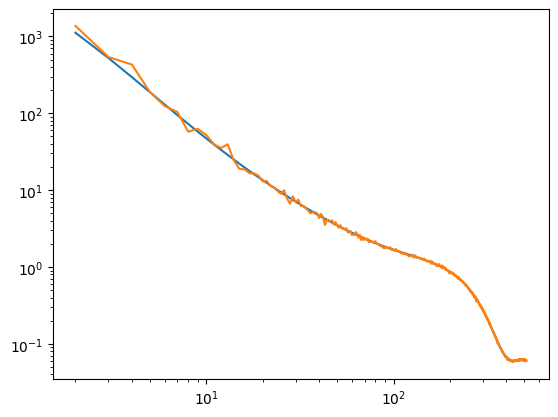

In [95]:
plt.plot(ells,cmb_th)
# plt.plot(cls[6,:])
plt.plot(ells,cls.mean(axis=0)[:511])

# plt.plot(hp.anafast(map[6,:],lmax=381))
plt.xscale('log')
plt.yscale('log')

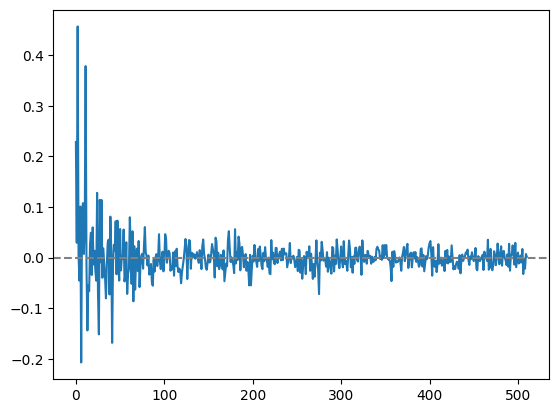

In [97]:
raw_bias=(cls.mean(axis=0)[:lmax-1]-cmb_th)/cmb_th
plt.plot(raw_bias)
plt.axhline(0, linestyle="--", color="gray")
# plt.xscale('log')

In [98]:
map=np.tile(map, (1, n_freqs))
map = map.reshape(nsims,n_freqs, npix)
print(map.shape)

(10, 7, 786432)


In [99]:
def compute_decoupled_cl_2( maps: np.ndarray, masks:np.ndarray, X:bool, nsides:int, l_max:int, n_freq:int)-> np.ndarray:
    """
    Compute the power spectra using NaMaster for a set of frequency maps.

    Parameters:
    - maps: numpy array of shape (n_freqs, n_maps) containing the frequency maps
    - masks: mask to apply to the maps
    - X: flag to indicate if the input maps are masked
    - nsides: resolution parameter for the maps
    - l_max: maximum multipole for the power spectra
    - n_freq: number of frequency channels

    Returns:
    - p_cl: raw power spectrum (coupled)
    - matrix: mode coupling matrix
    - cldec: decoupled power spectrum
    """
    p_cl =np.zeros((l_max+1, n_freq, n_freq))
    cldec = np.zeros((l_max+1, n_freq, n_freq))
    

    # Loop over all pairs of frequency maps (cross-power spectra)
    for i in range(n_freq):
        for j in range(i, n_freq):  # Compute only upper triangle (symmetric matrix)
            
            # Define the masked fields for the two maps
            f_i = nmt.NmtField(1 - masks, [maps[i, :]], masked_on_input=X, lmax=l_max) 
            f_j = nmt.NmtField(1 - masks, [maps[j, :]], masked_on_input=X, lmax=l_max) 
            
            if X==True:
                p_cl[:,i,j]= hp.anafast(maps[i,:], maps[j,:], lmax=l_max)
            else:
                
                # Compute the coupled power spectrum for (i, j)
                masked_map_i= (1-masks)*maps[i, :]
                masked_map_j= (1-masks)*maps[j,:]
                p_cl[:,i,j]= hp.anafast(masked_map_i, masked_map_j, lmax=l_max)
            
            # p_cl[:, i, j] = nmt.compute_coupled_cell(f_i, f_j)
            


            # Define a NaMaster binning scheme (no binning)
            b = nmt.NmtBin.from_lmax_linear(l_max, 1)

            # Create NaMaster workspace and get the coupling matrix
            w = nmt.NmtWorkspace.from_fields(f_i, f_j, b)
            #w = nmt.NmtWorkspace()
            w.compute_coupling_matrix(f_i, f_j, b)
        
            #w.compute(f_i, f_j, b)
            matrix = w.get_coupling_matrix() #lxl

            # Compute the inverse of the mode-coupling matrix
            matrix_inv = np.linalg.pinv(matrix, rcond=1e-6)

            # Compute the decoupled power spectrum using Einstein summation
            cldec[:, i, j] = np.einsum('ij,j->i', matrix_inv, p_cl[:, i, j])

            # Since Cl is symmetric, copy the value to (j, i)
            if i != j:
                cldec[:, j, i] = cldec[:, i, j]
                p_cl[:, j, i] = p_cl[:, i, j]
    return cldec

In [100]:
hilc= apply_HILC(map[0,:,:])
hilc_cl= compute_decoupled_cl_2(hilc, mask, False, nside, lmax, n_freqs)
dec_input= compute_decoupled_cl_2(map[0,:,:], mask, False, nside, lmax, n_freqs)

ValueError: Incompatible map!

In [22]:
print(hilc_cl.shape)
print(dec_input.shape)

(257, 7, 7)
(257, 7, 7)


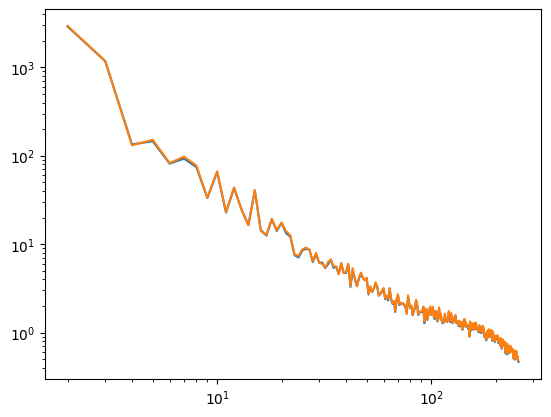

In [24]:
plt.plot(ells,hilc_cl[:255,0,0])
plt.plot(ells,dec_input[:255,0,0])
plt.xscale('log')
plt.yscale('log')

Running HILC

In [117]:
cls_sims=[]
alm_size=hp.Alm.getsize(lmax)
clean_maps_all = np.zeros((nsims, npix))
#nsims x nfreqs x npix  SELF GEN

for i in range(nsims):
    print ("processing simulation %d" % i)
    noise, dust, sync, ff,_= simulate_planck_maps(nside, freq)
    # map_out=apply_HILC(map[i,:,:]+noise+dust+sync+ff, lmax) #
    mask = cosine_smoothed_mask(nside)
    mask= (mask*(-1))+1
   
    cl_dec=compute_decoupled_cl_2(map[i,:,:]+noise+dust+sync+ff, mask, False, nside, lmax, n_freqs)
    _, weights = compute_weights(n_freqs, lmax, cl_dec)
    
    """sum_weights = np.sum(weights, axis=0)
    if np.all(np.isclose(sum_weights, 1.0)):
        print(f"✅ Weights sum to 1.000000.")
    else:
        print(f"⚠️ Warning: Weights do not sum to 1!")
        
    img=plt.imshow(weights, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label="Weight")
    plt.xlabel("Multipole $\\ell$")
    plt.ylabel("Frequency Index")
    plt.title("Weights as a Function of Frequency and Multipole")
    plt.show()"""
    
    _, alm_masked= mask_maps(map[i,:,:]+noise+dust+sync+ff, mask, alm_size,lmax, n_freqs, npix)
    alm_ilc=compute_alm_ilc(alm_masked, alm_size, weights, lmax)
    clean_maps= hp.alm2map(alm_ilc, nside, lmax) #, mmax=None
    clean_maps_all[i] = clean_maps
    clean_maps=np.tile(clean_maps, (1, n_freqs))
    clean_maps= clean_maps.reshape(n_freqs, npix)
    cl_out=compute_decoupled_cl_2(clean_maps, mask,True, nside, lmax, n_freqs)
    cls_sims.append(cl_out)

cls_sims=np.array(cls_sims)

processing simulation 0
processing simulation 1
processing simulation 2
processing simulation 3
processing simulation 4
processing simulation 5
processing simulation 6
processing simulation 7
processing simulation 8
processing simulation 9


In [118]:
print(cls_sims.shape)

(10, 513, 7, 7)


In [119]:
cls_mean = np.mean(cls_sims[:,:,0,0], axis=0)  # Mean recovered Cl
cls_std = np.std(cls_sims[:,:,0,0], axis=0)  # Standard deviation (scatter)
cls_error = (cls_std / np.sqrt(nsims))  # Error in mean estimate
bias = (cls_mean[:lmax-1] - cmb_th)/cmb_th

In [120]:
print(bias.shape)

(511,)


In [121]:
print(cls_mean.shape)

(513,)


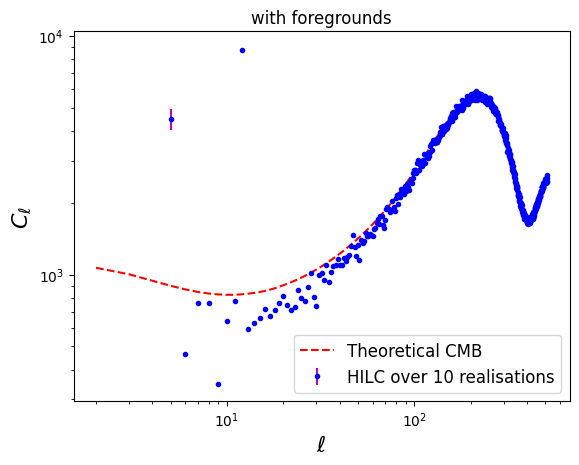

In [140]:
plt.errorbar(ells,norm*cls_mean[:lmax-1],yerr=cls_error[:lmax-1],ecolor='m', fmt= 'b.', label='HILC over 10 realisations')
plt.plot(ells,norm*cmb_th, 'r--',label='Theoretical CMB')

# plt.plot(ells,norm*cls_mean[:255], 'b.',label='HILC over 10 realisations')
# plt.plot(ells,norm*cls.mean(axis=0)[:255], 'g-',label='Mean sim cmb maps')
# plt.plot(dec[:,0,0], 'g-')

plt.xlabel('$\\ell$', fontsize=16)
plt.ylabel('$C_\\ell$', fontsize=16)
plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e-2,10)
plt.title("with foregrounds")
plt.legend(fontsize=12)
plt.show()

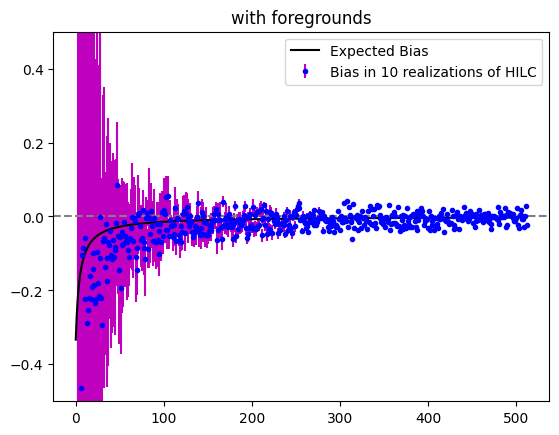

In [134]:
plt.errorbar(ells,bias, yerr= cls_error[:lmax-1], ecolor='m', label="Bias in 10 realizations of HILC", fmt='b.') 
# plt.plot(bias, 'b-',label="Bias in 10 realizations hilc") 
plt.plot(-3/(2*ells[2:]+1), label="Expected Bias", color="black")
plt.axhline(0, linestyle="--", color="gray")
# plt.xscale("log")
plt.legend()
plt.title("with foregrounds")
plt.ylim(-0.5, 0.5)
plt.show()

Text(0.5, 1.0, 'with foregrounds')

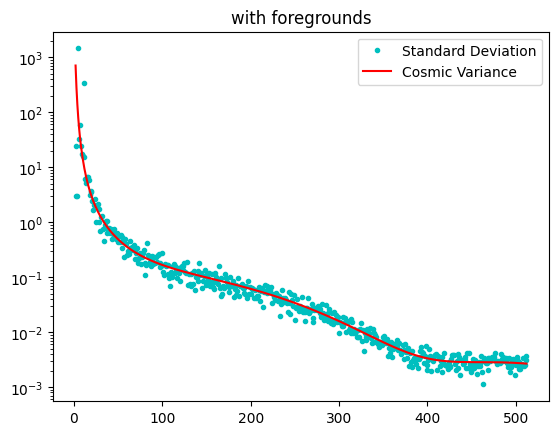

In [135]:
sigma_theory = np.sqrt(2 / (2 * ells + 1)) * cmb_th
plt.plot(ells,cls_std[:lmax-1], 'c.',label="Standard Deviation")
plt.plot(ells,sigma_theory, 'r-',label="Cosmic Variance")
plt.yscale("log")
plt.legend()
plt.title("with foregrounds")

In [130]:
final_map = hp.synfast(cls_mean, nside, lmax=lmax)

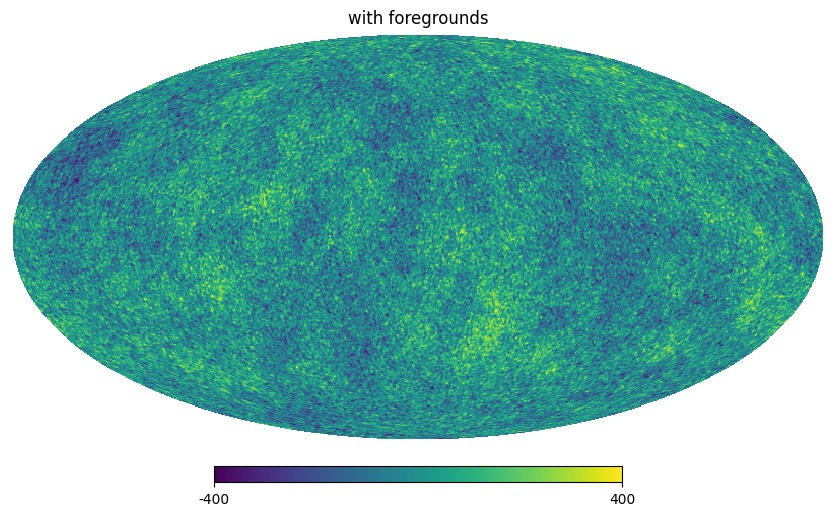

In [136]:
hp.mollview(final_map, min=-400, max=400, title="with foregrounds")

(786432,)


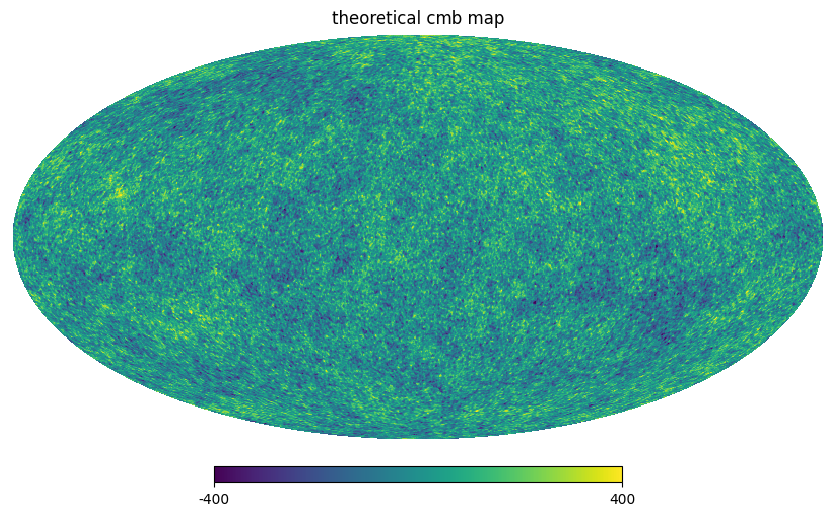

In [132]:
true_cmb_map=hp.synfast(cmb_th, nside, lmax=lmax)
print(true_cmb_map.shape)
hp.mollview(true_cmb_map, min=-400, max=400, title="theoretical cmb map")
# hp.mollview(true_cmb_map- final_map, min=-400, max=400)